<a href="https://colab.research.google.com/github/Jude-Ufoh/Pytorch/blob/main/Linear%20Regression/Pytorch1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!nvidia-smi


/bin/bash: line 1: nvidia-smi: command not found


In [3]:
import torch

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print(torch.__version__)


2.10.0+cpu


In [4]:
x = torch.tensor([[1, 2], [3,4],[6,5]])
print(x.ndim)
x[0]

2


tensor([1, 2])

### Random Tensors

In [5]:
x= torch.rand(3,2,2)
x

tensor([[[0.0528, 0.9938],
         [0.7230, 0.6150]],

        [[0.9067, 0.3356],
         [0.6073, 0.6070]],

        [[0.6612, 0.9249],
         [0.6545, 0.5313]]])

### zeros and ones

In [6]:
zeros = torch.zeros(3,4)
ones = torch.ones(3,4)
zeros, ones

(tensor([[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]),
 tensor([[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]))

### Creating a tensor range
A tensor range is created using functions like arange() (step-based) or linspace() (evenly spaced values)

In [7]:
# creating a range

y= torch.arange(2,5,1)
y

tensor([2, 3, 4])

### Getting information from tensors

In [8]:
z= torch.rand(1,3,4)
z

tensor([[[0.5478, 0.8865, 0.8701, 0.9246],
         [0.1758, 0.0842, 0.9474, 0.2741],
         [0.1199, 0.1454, 0.7594, 0.6086]]])

In [9]:
z.dtype
z.size()

torch.Size([1, 3, 4])

## Tensor Aggregation

In [10]:
x = torch.arange(0,100,5)
x.size()

torch.Size([20])

In [11]:
x.type(torch.float32).mean()

tensor(47.5000)

In [12]:
torch.mean(x.type(torch.float32))

tensor(47.5000)

In [13]:
y= torch.rand(3,6)
y

tensor([[0.7263, 0.9976, 0.3531, 0.5991, 0.1586, 0.5980],
        [0.6396, 0.5629, 0.0346, 0.2288, 0.6568, 0.2371],
        [0.9857, 0.9491, 0.5063, 0.3755, 0.5562, 0.2650]])

In [14]:
y.argmin()

tensor(8)

In [15]:
z=torch.arange(1,8)
z

tensor([1, 2, 3, 4, 5, 6, 7])

In [16]:
z1=z.reshape(1,7)
z1.shape


torch.Size([1, 7])

In [17]:
z_stacked = torch.stack([z,z,z,z], dim=1)
z_stacked

tensor([[1, 1, 1, 1],
        [2, 2, 2, 2],
        [3, 3, 3, 3],
        [4, 4, 4, 4],
        [5, 5, 5, 5],
        [6, 6, 6, 6],
        [7, 7, 7, 7]])

In [18]:
a= torch.rand(1,2,1,4)
a

tensor([[[[0.9817, 0.5155, 0.3965, 0.4896]],

         [[0.5787, 0.4137, 0.1334, 0.4038]]]])

In [19]:
b = torch.arange(1, 10).reshape(1, 3, 3)
b, b.shape



(tensor([[[1, 2, 3],
          [4, 5, 6],
          [7, 8, 9]]]),
 torch.Size([1, 3, 3]))

In [20]:
b[:,1,2]

tensor([6])

In [21]:
import numpy as np

a = np.random.rand(2, 3)
t = torch.from_numpy(a)

In [22]:
a[0, 0] = 999
print(t)

tensor([[9.9900e+02, 6.4751e-01, 9.4861e-01],
        [4.1173e-01, 6.5113e-01, 5.7800e-01]], dtype=torch.float64)


## Pytorch Workflow (Linear regression)

In [23]:
import torch
from torch import nn
import matplotlib.pyplot as plt
#checking the version of pytorch
torch.__version__

'2.10.0+cpu'

# Getting Data

In [24]:
# we will use a simple regression formula to create single features and single labels
# formula y =mX + C where m= Weight = 0.7 and C= bias= 0.3 and y =label, X = features
# using pytorch to create the values of X starting from 0, and ending at 1 with increament of 0.02 and corresponding values of y
X= torch.arange(0,1,0.02).unsqueeze(dim=1)

y= 0.7*X + 0.3

X[:10], y[:10]


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [25]:
# Splitting the data into Training (80%) and testing sets (20%)
splitting_factor = int(0.8*len(X))

#Using the splitting factor to partition the the X and y data
X_train, y_train = X[:splitting_factor], y[:splitting_factor]
X_test, y_test = X[splitting_factor:], y[splitting_factor:]


In [26]:
# Creatin a function to visualise our data
def plot_data(train_features= X_train,
              train_labels=y_train,
              test_features=X_test,
              test_labels=y_test,
              predictions=None):
  """
  Plots training data, test data and compares predictions
  """
  plt.figure(figsize=(8,5))
  # Plot training data in  blue
  plt.scatter(train_features, train_labels, c="b", s=4, label="Training data")
  # Plot test data in green
  plt.scatter(test_features, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the prediction in red(if predictions were made on the test)
    plt.scatter(test_features, predictions, c="r", s=4, label="Predictions")
  # Show the legend
  plt.legend(prop={"size": 14})
  plt.show()

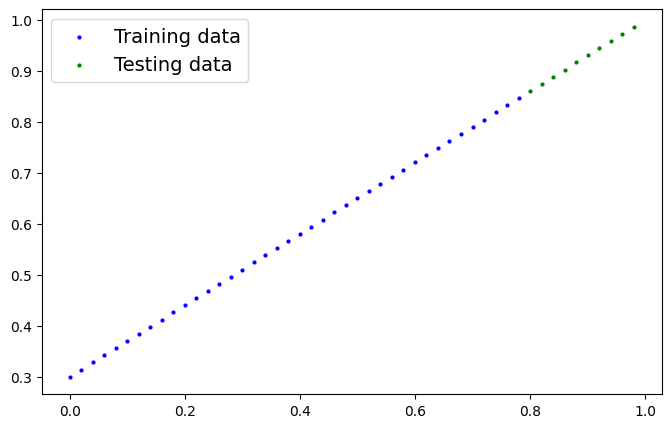

In [27]:
plot_data()

In [28]:
# Creating a Linear Regression model class
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights =nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
  # Forward method to define the computation in the model
  def forward(self, x: torch.Tensor) ->torch.Tensor:
    return self.weights * x + self.bias


In [ ]:
# creating a manual seed
torch.manual_seed(42)

#creating an instance of the model
model_0 = LinearRegressionModel()

# checkout the parameters
list(model_0.parameters())

#checking the state of the model
list(model_0.parameters())

In [30]:
# Using torch.inference_mode() to make prediction (this is only used when the model is being used to make a prediction)
with torch.inference_mode():
  y_preds = model_0(X_test)

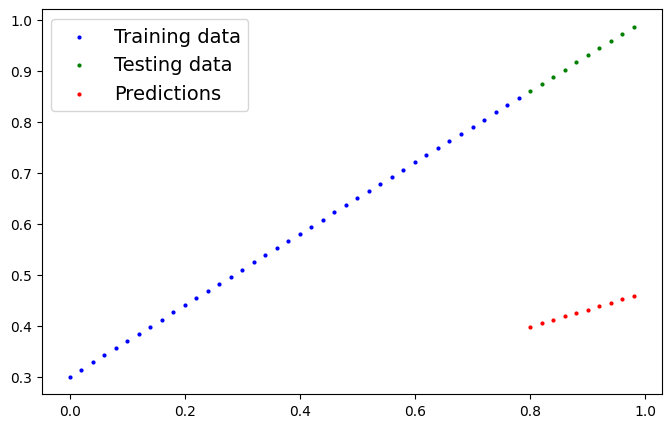

In [31]:
# We now have prediction. Let's checkout what the plot looks like
plot_data(predictions=y_preds)

In [32]:
#Checking y_test-y_pred
y_test-y_preds

tensor([[0.4618],
        [0.4691],
        [0.4764],
        [0.4836],
        [0.4909],
        [0.4982],
        [0.5054],
        [0.5127],
        [0.5200],
        [0.5272]])

In [33]:
#### from the last graph and last result, it is clear that model is doing very bad.
#### this is is because it has not been trained.
#### to train it, we will need a loss function and optimiser

loss_fn = nn.L1Loss()

#Create the optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)


In [38]:
# Next we train the model for 100 epochs
epochs = 100

train_loss_values =[]
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
  model_0.train()
  y_pred = model_0(X_train)
  loss = loss_fn(y_pred, y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  #Testing
  model_0.eval()
  with torch.inference_mode():
    test_pred = model_0(X_test)
    test_loss = loss_fn(test_pred,y_test.type(torch.float))

    if epoch % 10 == 0:
      epoch_count.append(epoch)
      train_loss_values.append(loss.detach().numpy())
      test_loss_values.append(test_loss.detach().numpy())
      print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss}")

Epoch: 0 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882
Epoch: 10 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882
Epoch: 20 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882
Epoch: 30 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882
Epoch: 40 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882
Epoch: 50 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882
Epoch: 60 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882
Epoch: 70 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882
Epoch: 80 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882
Epoch: 90 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882
